# Online Retail Veri Seti Analizi
  Dönem Projesi — [Ayşe Esra Arslan], [1306240093]


## 1. Kütüphanelerin İçe Aktarılması
Bu bölümde veri okuma, görselleştirme ve modelleme için gereken kütüphaneleri içe aktarıyoruz.

In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd                     # tablo (DataFrame) işlemleri için — projenin belkemiği
import numpy as np                      # sayısal hesaplamalar için
import matplotlib.pyplot as plt         # temel grafik çizimi
import seaborn as sns                   # daha gelişmiş/okunaklı görselleştirme
from sklearn.preprocessing import StandardScaler  # kümeleme öncesi veriyi ölçeklendirmek için
from sklearn.cluster import KMeans                 # kümeleme (clustering) modeli

# Grafiklerin notebook içinde direkt görünmesini sağlıyoruz
%matplotlib inline

# Grafiklerin görünümünü biraz daha sade/okunaklı yapan bir stil ayarı
sns.set_style("whitegrid")

## 2. Veri Setinin Yüklenmesi
Kullanılan veri seti: UCI Machine Learning Repository, "Online Retail" veri seti
(Chen, D. (2015), https://doi.org/10.24432/C5BW33, CC BY 4.0 lisansı).
2010-2011 yılları arasında bir İngiliz online hediye firmasının 541.909 satırlık
gerçek satış kaydını içerir.

In [2]:
# Veri setini oku (tek sayfalık bir Excel dosyası)
df = pd.read_excel("data/online_retail.xlsx")

# İlk 5 satıra bakarak veri yapısını gözle kontrol ediyoruz
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Veri Setinin Genel Yapısının İncelenmesi
Veriyi modellemeden önce sütun tiplerini ve eksik veri durumunu gözden geçiriyoruz.

In [3]:
# Veri setinin boyutu: (satır sayısı, sütun sayısı)
print("Veri seti boyutu:", df.shape)

# Her sütunun veri tipi ve eksik olmayan (non-null) değer sayısı
df.info()

Veri seti boyutu: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 4. Veri Temizleme
Bu bölümde eksik değerleri, geçersiz işlemleri (iptal/iade) ve hatalı tip
dönüşümlerini ele alıyor, modellemeye hazır temiz bir veri seti oluşturuyoruz.

### 4.1 Eksik Değerlerin Tespiti

In [4]:
# Her sütunda kaç eksik (NaN) değer var?
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### 4.2 Eksik CustomerID Satırlarının Çıkarılması

In [5]:
# CustomerID eksik olan satırları veri setinden çıkarıyoruz.
# Sebep: ileride müşteri segmentasyonu (kümeleme) yapacağız, bu da her satırın
# hangi müşteriye ait olduğunu bilmemizi gerektiriyor. Müşterisi belirsiz bir
# satırı bir segmente atayamayız, dolayısız bu satırlar bu analiz için kullanılamaz.
df = df.dropna(subset=["CustomerID"])

### 4.3 İptal İşlemlerinin ve Geçersiz Satırların Çıkarılması

In [6]:
# İptal edilen faturaları çıkar: bu veri setinde fatura numarası 'C' ile
# başlıyorsa, o fatura bir iptal/iade işlemidir (gerçek satış değildir).
df = df[~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")]

# Negatif veya sıfır miktar/fiyat içeren satırları çıkar — bunlar da iade,
# hatalı kayıt veya promosyon ürünü olabilir; gerçek bir satışı temsil etmiyor.
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

### 4.4 Tip Dönüşümü ve Yeni Değişken Türetme

In [7]:
# CustomerID şu an ondalıklı (örn. 17850.0) görünüyor, bu mantıksız çünkü
# müşteri numarası bir tam sayıdır. Tam sayıya çeviriyoruz.
df["CustomerID"] = df["CustomerID"].astype(int)

In [8]:
# Her satır için toplam satış tutarını hesaplıyoruz (adet x birim fiyat).
# Bu sütunu hem EDA'da hem de RFM modellemesinde (Monetary değeri) kullanacağız.
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

### 4.5 Temizlik Sonrası Kontrol

In [9]:
# Temizlik sonrası veri setinin yeni boyutu
print("Temizlik sonrası veri seti boyutu:", df.shape)

# Sayısal sütunların özet istatistikleri (ortalama, min, max, çeyrekler vb.)
df.describe()

Temizlik sonrası veri seti boyutu: (397884, 9)


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


## 5. Keşifsel Veri Analizi (EDA) ve Araştırma Soruları

Bu projede yanıtlanacak 3 araştırma sorusu:

**Soru 1:** Hangi ülkeler ve hangi ürünler toplam satış gelirine en çok katkı sağlıyor?

**Soru 2:** Satışlarda zaman içinde (aylık bazda) belirgin bir trend veya mevsimsellik
var mı?

**Soru 3:** Müşterileri satın alma davranışlarına (Recency, Frequency, Monetary) göre
segmentlere ayırdığımızda, birbirinden anlamlı şekilde farklı müşteri grupları ortaya
çıkıyor mu? (Bu soru, Bölüm 7'deki kümeleme modeliyle yanıtlanacaktır.)

### 5.1 Genel Özet İstatistikler

In [10]:
# İş açısından anlamlı temel sayılar
print("Toplam benzersiz fatura sayısı:", df["InvoiceNo"].nunique())
print("Toplam benzersiz müşteri sayısı:", df["CustomerID"].nunique())
print("Toplam benzersiz ürün çeşidi sayısı:", df["StockCode"].nunique())
print("Faaliyet gösterilen ülke sayısı:", df["Country"].nunique())
print("Toplam satış geliri (£):", round(df["TotalPrice"].sum(), 2))


Toplam benzersiz fatura sayısı: 18532
Toplam benzersiz müşteri sayısı: 4338
Toplam benzersiz ürün çeşidi sayısı: 3665
Faaliyet gösterilen ülke sayısı: 37
Toplam satış geliri (£): 8911407.9


### 5.2 Görselleştirme 1 - Ülkelere Göre Toplam Satış Geliri (Bar Chart)

İngiltere'nin toplam gelirdeki payı: %82.0


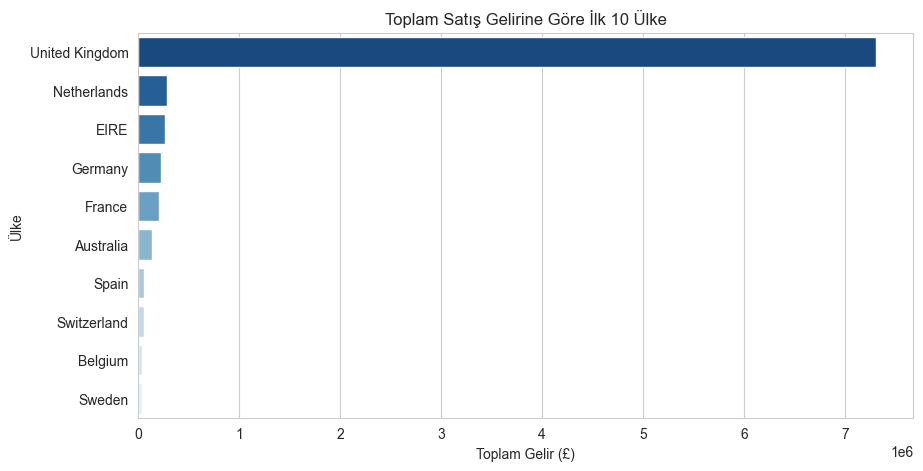

In [11]:
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

uk_share = top_countries["United Kingdom"] / df["TotalPrice"].sum() * 100
print(f"İngiltere'nin toplam gelirdeki payı: %{uk_share:.1f}")

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="Blues_r", legend=False)
plt.title("Toplam Satış Gelirine Göre İlk 10 Ülke")
plt.xlabel("Toplam Gelir (£)")
plt.ylabel("Ülke")
plt.show()

### 5.3 Görselleştirme 2 - Adede Göre En Çok Satılan 10 Ürün (Bar Chart)
Soru 1'in ikinci yarısını (hangi ürünler) burada inceliyoruz.

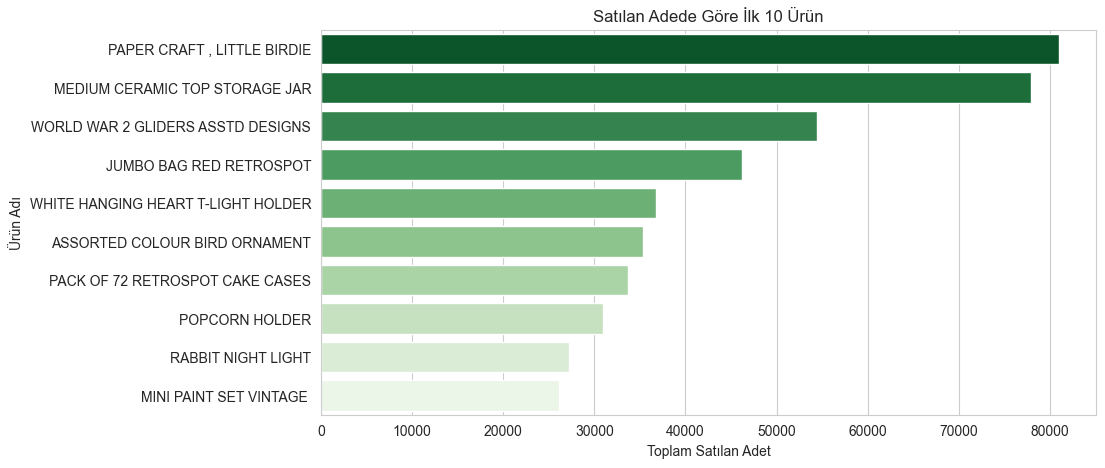

In [12]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="Greens_r", legend=False)
plt.title("Satılan Adede Göre İlk 10 Ürün")
plt.xlabel("Toplam Satılan Adet")
plt.ylabel("Ürün Adı")
plt.show()

### 5.4 Görselleştirme 3 - Aylara Göre Toplam Satış Geliri (Line Chart)
Soru 2'yi (zaman içindeki trend/mevsimsellik) burada inceliyoruz.

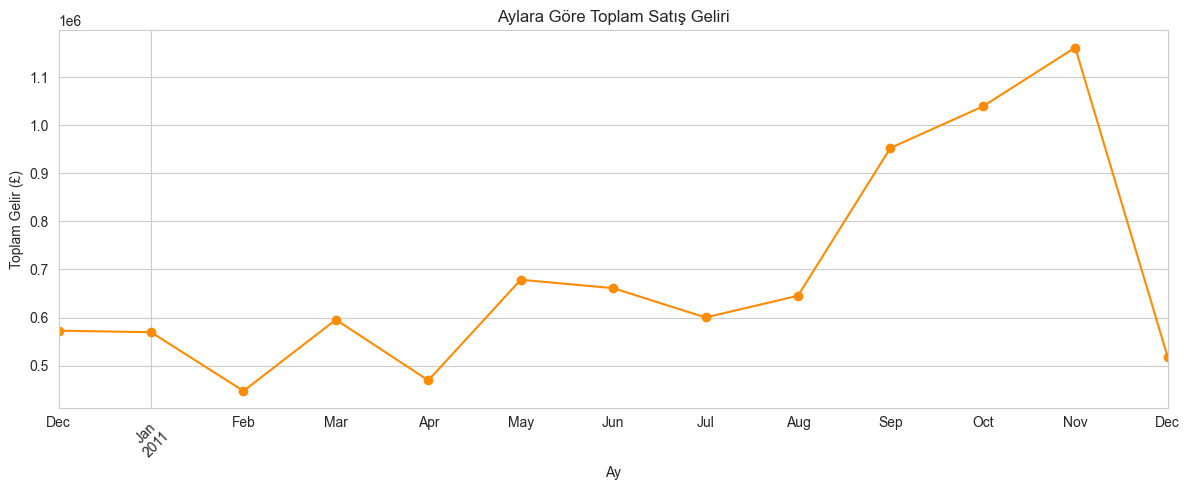

In [13]:
# InvoiceDate sütunundan "ay" bilgisini çıkarıyoruz (örn: 2011-03)
# .dt.to_period("M") tarihi gün bazından ay bazına indirir, aynı aydaki
# tüm günleri tek bir grup haline getirir.
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("InvoiceMonth")["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind="line", marker="o", color="darkorange")
plt.title("Aylara Göre Toplam Satış Geliri")
plt.xlabel("Ay")
plt.ylabel("Toplam Gelir (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.5 Görselleştirme 4 - Fatura Bazında Sipariş Tutarı Dağılımı (Histogram)
Tipik bir siparişin büyüklüğünü ve dağılımın şeklini (simetrik mi, çarpık mı)
incelemek için.

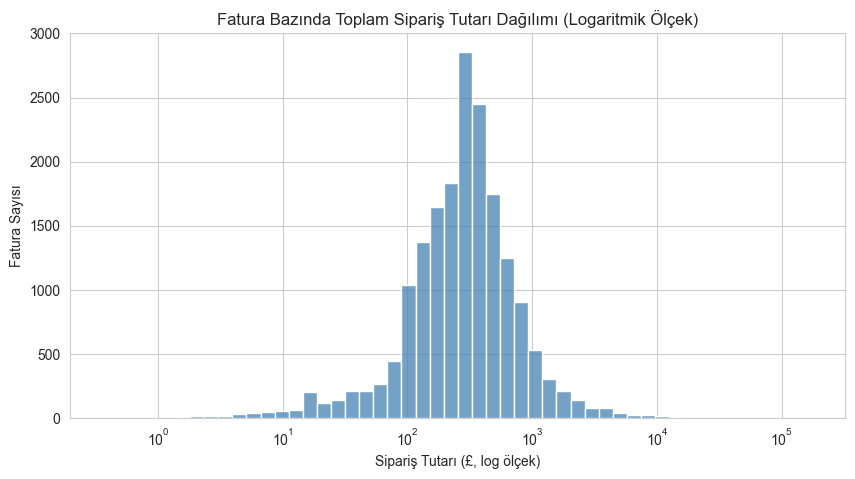

In [14]:
order_values = df.groupby("InvoiceNo")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
sns.histplot(order_values, bins=50, color="steelblue", log_scale=True)
plt.title("Fatura Bazında Toplam Sipariş Tutarı Dağılımı (Logaritmik Ölçek)")
plt.xlabel("Sipariş Tutarı (£, log ölçek)")
plt.ylabel("Fatura Sayısı")
plt.show()

### 5.6 Görselleştirme 5 - Quantity ve UnitPrice için Aykırı Değer İncelemesi (Boxplot)

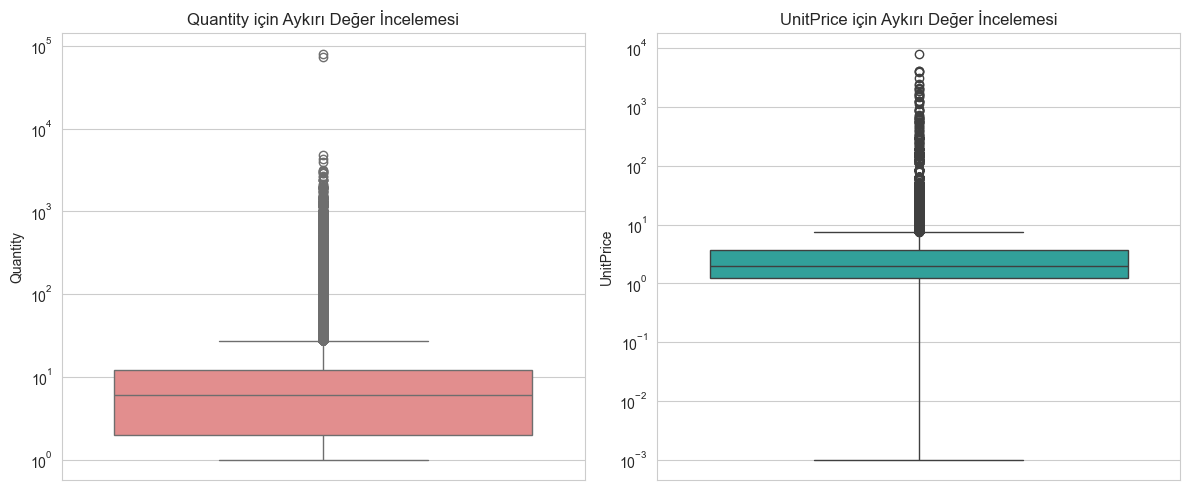

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["Quantity"], ax=axes[0], color="lightcoral")
axes[0].set_title("Quantity için Aykırı Değer İncelemesi")
axes[0].set_yscale("log")

sns.boxplot(y=df["UnitPrice"], ax=axes[1], color="lightseagreen")
axes[1].set_title("UnitPrice için Aykırı Değer İncelemesi")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

### 5.7 Aykırı Değer Kararı (Veri Temizliğinin Tamamlanması)
Boxplot incelemesinde Quantity ve UnitPrice sütunlarında istatistiksel olarak aykırı
sayılabilecek yüksek değerler tespit edildi. Ancak veri seti açıklamasında firmanın
müşterilerinin büyük kısmının toptancı (wholesaler) olduğu belirtiliyor; bu nedenle
yüksek miktarlı satışların bir kısmı muhtemelen gerçek toptan satışlardır, veri hatası
değildir. Bu yüzden satırları tamamen silmek yerine, üst %1'lik dilimdeki en uç
değerleri 99. yüzdelik dilim (percentile) seviyesine kırpıyoruz (clip/capping) —
böylece hem aşırı uç değerlerin ileride kümeleme modelini bozması önleniyor hem de
veri/satır kaybı minimumda tutuluyor. Not: Yukarıdaki 5.2-5.6 grafikleri ham (kırpılmamış)
veriyle çizildi — bu, gerçek dağılımı olduğu gibi görmek için kasıtlıydı. Bölüm 7'deki
modellemede ise kırpılmış (capped) versiyon kullanılacaktır.

In [16]:
# IQR yöntemiyle teorik üst sınırı hesaplayıp gözlemliyoruz (bilgi amaçlı)
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
IQR = Q3 - Q1
iqr_upper_limit = Q3 + 1.5 * IQR
print("IQR yöntemine göre Quantity üst sınırı:", iqr_upper_limit)
print("Bu sınırın üzerindeki satır sayısı:", (df["Quantity"] > iqr_upper_limit).sum())

# Karar: IQR sınırı çok düşük çıkıyor (B2C davranışına göre kalibre), bu yüzden
# onun yerine 99. percentile'ı kullanıyoruz — daha az agresif, toptan satışları
# büyük ölçüde koruyor.
qty_cap = df["Quantity"].quantile(0.99)
price_cap = df["UnitPrice"].quantile(0.99)

# .clip(upper=...) : bu değerin ÜZERİNDEKİ her şeyi bu değere indirir,
# satırı SİLMEZ — sadece aşırı uç değeri "törpüler".
df["Quantity"] = df["Quantity"].clip(upper=qty_cap)
df["UnitPrice"] = df["UnitPrice"].clip(upper=price_cap)

# TotalPrice'ı kırpılmış (güncellenmiş) değerlerle yeniden hesaplıyoruz
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("Quantity üst sınır (99. percentile):", qty_cap)
print("UnitPrice üst sınır (99. percentile):", price_cap)

IQR yöntemine göre Quantity üst sınırı: 27.0
Bu sınırın üzerindeki satır sayısı: 25647
Quantity üst sınır (99. percentile): 120.0
UnitPrice üst sınır (99. percentile): 14.95


**Soru 1 yanıtı:** Toplam satış gelirinin büyük çoğunluğu (yaklaşık %82.0) İngiltere'den geliyor; bu, veri setinin "UK-based
online retailer" tanımıyla tutarlı, diğer ülkeler (Hollanda, İrlanda, Almanya)
nispeten küçük paylara sahip. En çok satılan ürünler ("Paper Craft Little Birdie",
"Medium Ceramic Top Storage Jar" vb.) genellikle dekoratif ev eşyaları ve hediyelik
ürünler — bu da firmanın "unique all-occasion gifts" sattığı bilgisiyle örtüşüyor.

**Soru 2 yanıtı:** Aylık gelir, yıl içinde dalgalı bir şekilde Şubat'ta dip yapıp
Kasım ayına kadar (Eylül-Kasım arası özellikle hızlı) sürekli artıyor; bu, hediye
sektöründe yıl sonu/tatil alışveriş sezonuna hazırlık olarak yorumlanabilir.
Aralık 2011'deki sert düşüş ise mevsimsel bir gerileme değil, veri setinin o ayın
sadece ilk 9 gününü kapsamasından kaynaklanıyor.

## 6. Modelleme - RFM Analizi ve K-Means Kümeleme
Bu bölümde müşterileri satın alma davranışlarına göre segmentlere ayırarak
Soru 3'ü yanıtlıyoruz. Yöntem: RFM (Recency-Frequency-Monetary) metriklerinin
hesaplanması, ardından K-Means algoritmasıyla kümeleme.

### 6.1 RFM Metriklerinin Hesaplanması
- **Recency:** Müşterinin son alışverişinden bugüne kaç gün geçti (düşük = iyi)
- **Frequency:** Müşterinin kaç farklı fatura kestiği (yüksek = iyi)
- **Monetary:** Müşterinin toplam ne kadar harcadığı (yüksek = iyi)

In [17]:
# "Bugün" diye bir tarih yok, bu yüzden veri setindeki en son işlem tarihinden
# 1 gün sonrasını referans alıyoruz — Recency'yi buna göre hesaplayacağız.
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Referans tarih:", reference_date)

# Her müşteri (CustomerID) için 3 metriği aynı anda hesaplıyoruz.
# .agg() içindeki her satır: "SonuçSütunuAdı=(KaynakSütun, nasılHesaplanacağı)"
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm.head()

Referans tarih: 2011-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,124.80
1,12347,2,7,4185.20
2,12348,75,4,1530.03
3,12349,19,1,1443.50
4,12350,310,1,309.35


### 6.2 Verinin Ölçeklendirilmesi (Standardizasyon)
K-Means, müşteriler arası mesafeyi (Öklid mesafesi) hesaplayarak çalışır.
Monetary binlerce £ olabilirken Frequency 1-200 arası küçük sayılardır;
ölçeklendirmeden verilirse Monetary'nin büyük sayısal değeri mesafe hesabına
haksız şekilde ağırlık basar. StandardScaler her sütunu ortalaması 0, standart
sapması 1 olacak şekilde dönüştürür — böylece üç metrik de modele eşit ağırlıkta
katkı sağlar.

In [18]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

### 6.3 Optimal Küme Sayısının Belirlenmesi (Elbow Yöntemi)
K-Means'e kaç küme (k) oluşturacağını biz söylemek zorundayız. Elbow (dirsek)
yöntemi: farklı k değerleri için modeli deneyip "inertia" (küme içi toplam hata)
değerini grafiğe döküyoruz. Grafikte eğimin aniden yavaşladığı nokta ("dirsek"),
makul bir k değeridir — daha fazla küme eklemek artık anlamlı bir iyileşme
getirmiyor demektir.

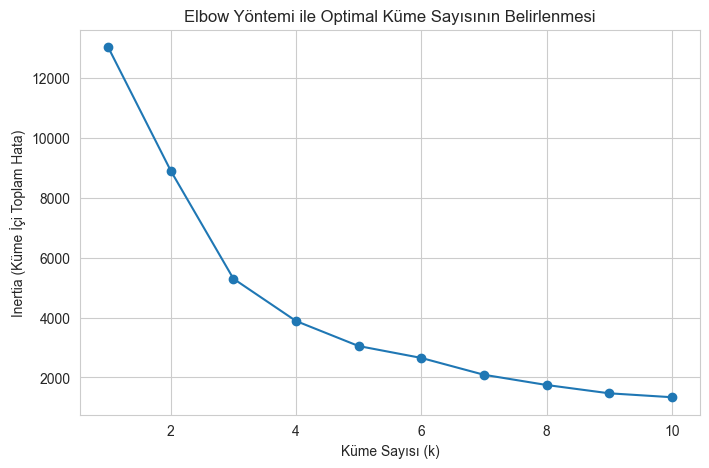

In [19]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(rfm_scaled)
    inertia_values.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.title("Elbow Yöntemi ile Optimal Küme Sayısının Belirlenmesi")
plt.xlabel("Küme Sayısı (k)")
plt.ylabel("Inertia (Küme İçi Toplam Hata)")
plt.show()

### 6.4 K-Means Modelinin Eğitilmesi
Elbow grafiğine göre k=[X] seçildi (X'i grafikten okunan değerle değiştir).

In [20]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,124.80,1
1,12347,2,7,4185.20,0
2,12348,75,4,1530.03,0
3,12349,19,1,1443.50,0
4,12350,310,1,309.35,1


### 6.5 Kümelerin Yorumlanması

In [21]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_summary["MüşteriSayısı"] = rfm["Cluster"].value_counts().sort_index()
cluster_summary

,Recency,Frequency,Monetary,MüşteriSayısı
Cluster,,,,
0,43.6,3.7,1296.1,3060
1,248.1,1.6,454.6,1070
2,12.1,23.0,10930.3,197
3,5.1,91.6,96357.0,11


### 6.6 Kümelerin Görselleştirilmesi

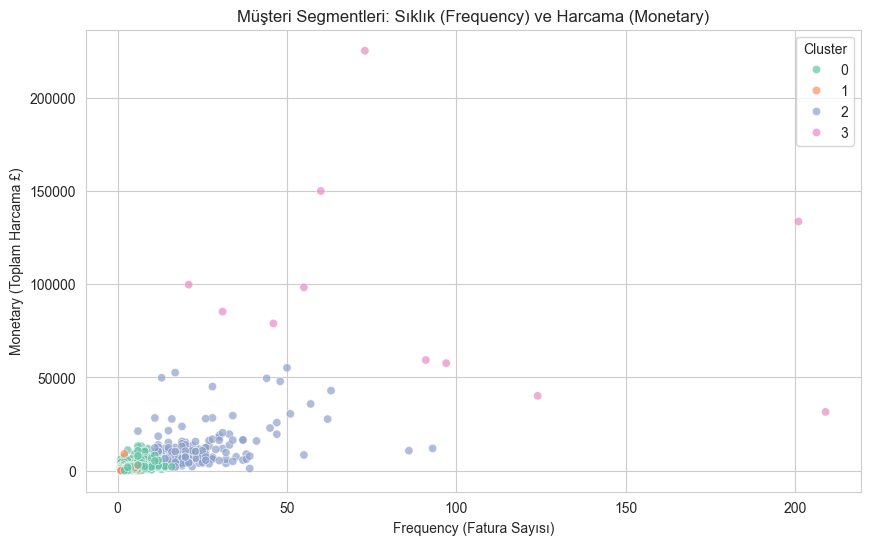

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="Set2", alpha=0.7)
plt.title("Müşteri Segmentleri: Sıklık (Frequency) ve Harcama (Monetary)")
plt.xlabel("Frequency (Fatura Sayısı)")
plt.ylabel("Monetary (Toplam Harcama £)")
plt.show()

### 6.7 Soru 3'ün Yanıtlanması

K-Means modeli, müşterileri 4 anlamlı şekilde farklı segmente ayırmıştır:

- **Küme 3 — Şampiyon/Toptan Müşteriler (11 müşteri):** Aşırı yüksek sıklık
(ortalama 91.6 fatura) ve harcama (£96,357), çok yakın zamanda alışveriş
yapmışlar (5.1 gün). Sayıca çok az olsalar da muhtemelen toptancı müşteriler,
firma için orantısız derecede değerliler.

- **Küme 2 — Sadık Yüksek Değerli Müşteriler (197 müşteri):** Yüksek sıklık
(23 fatura) ve harcama (£10,930), yakın zamanda alışveriş yapmışlar (12.1 gün).
Pazarlama açısından elde tutulması öncelikli ikinci grup.

- **Küme 0 — Standart/Düzenli Müşteriler (3060 müşteri, çoğunluk):** Ortalama
sıklık (3.7 fatura) ve harcama (£1,296), orta düzeyde yakın zamanlı (43.6 gün).
Müşteri tabanının büyük gövdesini oluşturuyor.

- **Küme 1 — Pasif/Kayıp Riski Taşıyan Müşteriler (1070 müşteri):** Düşük
sıklık (1.6 fatura) ve harcama (£454.6), en uzun süredir alışveriş yapmamış
grup (ortalama 248.1 gün, yaklaşık 8 ay). Bu segment, geri kazanım (win-back)
kampanyaları için hedef olabilir.

Bu sonuç, e-ticaret/pazarlama literatüründeki klasik RFM segmentasyon
mantığıyla örtüşüyor: az sayıda yüksek değerli müşteri toplam gelirin
orantısız bir kısmını oluştururken, büyük çoğunluk daha düşük/orta düzeyde
katkı sağlıyor (Pareto ilkesiyle uyumlu bir desen).